# 01 · Exploratory Data Analysis
### Fraud Risk Intelligence Platform

The engineered features live in PostgreSQL as the `txn_features` materialized view (see `sql/03_features.sql`). This notebook reads them straight from the database and asks one question of each feature family: **does it actually separate fraud from legit?**

The answers drive every later modeling decision, including the honest negative result that the geo features carry no signal on this synthetic dataset.

**Prereqts:** PostgreSQL running, `.env` set, project venv active (`source .venv/bin/activate`).

In [3]:
import sys
from pathlib import Path

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "db.py").exists():
        sys.path.insert(0, str(_p / "src"))
        PROJECT_ROOT = _p
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

NAVY, ORANGE, FRAUD, LEGIT, MUTED = "#22344A", "#E8853A", "#D64545", "#1F9D63", "#7C8A99"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#D7DEE6",
    "axes.grid": True, "grid.color": "#EAEFF4", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "figure.dpi": 110,
})

from db import get_engine
engine = get_engine()
print("Connected:", PROJECT_ROOT)

Connected: /Users/nihirasharma/Desktop/Portfolio/fraud-risk-intelligence-platform


In [4]:
# Pull the full engineered feature view (~1.3M rows; takes ~20-30s)
df = pd.read_sql("SELECT * FROM txn_features", engine)
print(f"{len(df):,} transactions  |  {int(df['is_fraud'].sum()):,} fraud")
df.head()

1,296,675 transactions  |  7,506 fraud


,trans_num,cc_num,trans_time,amt,category,is_fraud,txn_hour,txn_dow,is_weekend,is_night,cardholder_age,txn_count_24h,txn_count_7d,amt_sum_24h,amt_zscore,home_merchant_km,implied_kmh
0,98e3dcf98101146a577f85a34e58feec,60416207185,2019-01-01 12:47:15,7.27,misc_net,0,12,2,False,False,32,1,1,7.27,-0.398,127.61,NaN
1,498120fc45d277f7c88e3dba79c33865,60416207185,2019-01-02 08:44:57,52.94,gas_transport,0,8,3,False,False,32,2,2,60.21,-0.025,110.31,11.3
2,95f514bb993151347c7acdf8505c3d62,60416207185,2019-01-02 08:47:36,82.08,gas_transport,0,8,3,False,False,32,3,3,142.29,0.212,21.79,2382.3
3,4f0c1a14e0aa7eb56a490780ef9268c5,60416207185,2019-01-02 12:38:14,34.79,kids_pets,0,12,3,False,False,32,4,4,177.08,-0.173,87.20,22.9
4,3b2ebd3af508afba959640893e1e82bc,60416207185,2019-01-02 13:10:46,27.18,home,0,13,3,False,False,32,4,5,196.99,-0.235,74.21,245.1


## 1 · Class imbalance

Fraud is rare. This single fact shapes everything downstream: it rules out plain accuracy as a metric (predicting "never fraud" scores ~99.4%), forces PR-AUC over ROC-AUC and means models need class weighting.

Fraud rate: 0.579%   (7,506 of 1,296,675)


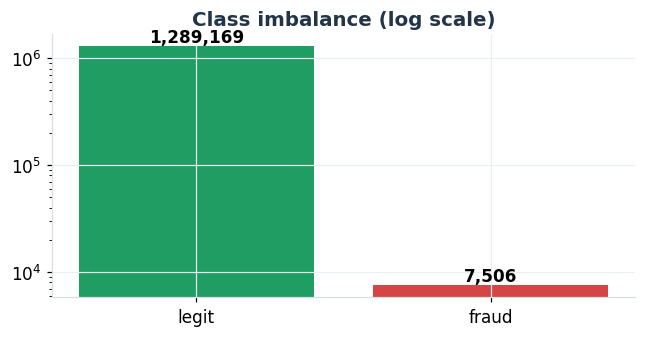

In [5]:
counts = df["is_fraud"].value_counts().sort_index()
rate = 100 * counts[1] / counts.sum()
print(f"Fraud rate: {rate:.3f}%   ({counts[1]:,} of {counts.sum():,})")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(["legit", "fraud"], counts.values, color=[LEGIT, FRAUD])
ax.set_yscale("log")
ax.set_title("Class imbalance (log scale)")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

## 2 · Amount deviation – the dominant signal

`amt_zscore` measures how unusual a transaction's amount is *for that card* (standard deviations from the card's own mean spend). The group means tell the story before any plot.

is_fraud
legit   -0.02
fraud    3.20
Name: amt_zscore, dtype: float64


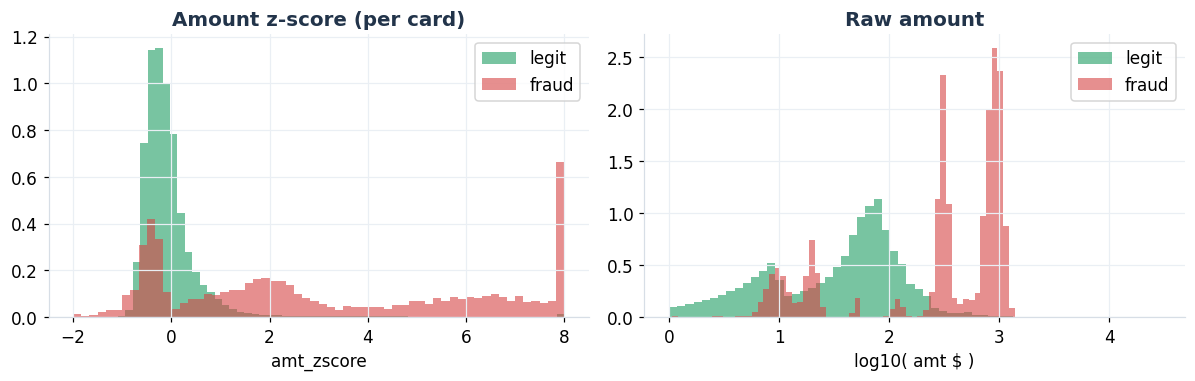

In [6]:
print(df.groupby("is_fraud")["amt_zscore"].mean().round(2).rename({0: "legit", 1: "fraud"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for lab, g, c in [("legit", 0, LEGIT), ("fraud", 1, FRAUD)]:
    axes[0].hist(df.loc[df.is_fraud == g, "amt_zscore"].clip(-2, 8), bins=60,
                 alpha=0.6, color=c, label=lab, density=True)
    axes[1].hist(np.log10(df.loc[df.is_fraud == g, "amt"].clip(lower=1)), bins=60,
                 alpha=0.6, color=c, label=lab, density=True)
axes[0].set_title("Amount z-score (per card)"); axes[0].set_xlabel("amt_zscore"); axes[0].legend()
axes[1].set_title("Raw amount"); axes[1].set_xlabel("log10( amt $ )"); axes[1].legend()
plt.tight_layout(); plt.show()

**Read:** legit transactions sit right at the card's normal spend (z ≈ −0.02); fraud sits at **z ≈ 3.2**, more than three standard deviations above. Fraudsters cash out with amounts wildly out of character for the card, and the per-card z-score captures it cleanly. This is the single strongest feature in the whole project.

## 3 · Geo features – a genuine negative result

Two geo features were engineered in SQL: `home_merchant_km` (cardholder home → merchant distance) and `implied_kmh` (implied travel speed since the previous transaction, for impossible-travel detection). Both sound predictive. Neither works here – and documenting *why* matters.

          home_merchant_km  implied_kmh
is_fraud                               
legit                 76.1        185.9
fraud                 76.3        750.4


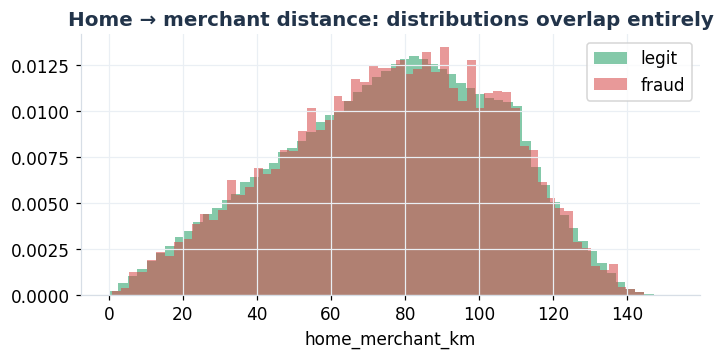

In [7]:
print(df.groupby("is_fraud")[["home_merchant_km", "implied_kmh"]].mean().round(1)
        .rename({0: "legit", 1: "fraud"}))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
for lab, g, c in [("legit", 0, LEGIT), ("fraud", 1, FRAUD)]:
    ax.hist(df.loc[df.is_fraud == g, "home_merchant_km"], bins=60, alpha=0.55,
            color=c, label=lab, density=True)
ax.set_title("Home → merchant distance: distributions overlap entirely")
ax.set_xlabel("home_merchant_km"); ax.legend()
plt.tight_layout(); plt.show()

**Read:** the two distance features tell the same story. `home_merchant_km` is essentially identical across classes (76.1 km legit vs 76.3 km fraud) and the distributions sit on top of each other. `implied_kmh` *looks* different in the means (≈186 legit vs ≈750 fraud), but that gap is an artifact of a few absurd outliers – random coordinate pairs produce impossible speeds (e.g. 2,382 km/h between two ordinary legit transactions in the sample above), and the mean is highly sensitive to them; the bulk of the distribution shows no separation. The cause is structural: **Sparkov is synthetic and scatters merchant coordinates randomly around each cardholder** rather than modeling real movement, so distance carries no reliable signal.

That's why `implied_kmh` is dropped from the modeling matrix and `home_merchant_km` is kept only to document the finding. For the write-up: *"engineered and empirically tested geo-distance and impossible-travel features; neither carries usable signal on this dataset due to synthetic coordinate generation."* A reported negative reads as more credible, not less.

## 4 · Velocity – a mild signal

`txn_count_24h` counts a card's transactions in the trailing 24 hours (a true time-based rolling window in SQL).

is_fraud
legit    4.88
fraud    5.23
Name: txn_count_24h, dtype: float64


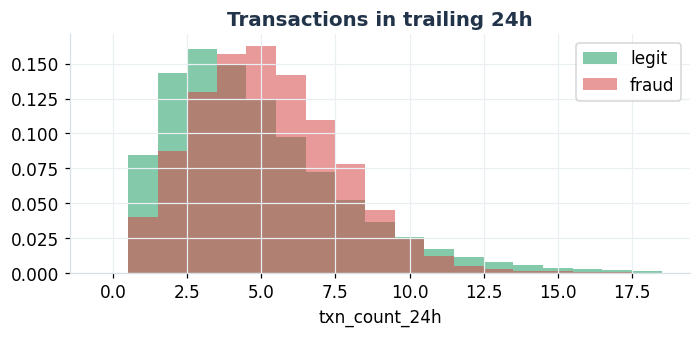

In [8]:
print(df.groupby("is_fraud")["txn_count_24h"].mean().round(2).rename({0: "legit", 1: "fraud"}))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bins = np.arange(0, 20) - 0.5
for lab, g, c in [("legit", 0, LEGIT), ("fraud", 1, FRAUD)]:
    ax.hist(df.loc[df.is_fraud == g, "txn_count_24h"], bins=bins, alpha=0.55,
            color=c, label=lab, density=True)
ax.set_title("Transactions in trailing 24h"); ax.set_xlabel("txn_count_24h"); ax.legend()
plt.tight_layout(); plt.show()

**Read:** 5.23 (fraud) vs 4.88 (legit) – a real but small lift. Worth a modest weight in the rule engine and a few splits in the trees, not a headline feature.

## 5 · Which categories concentrate fraud?

Fraud rate per merchant category. (Note: a category-level fraud-rate *feature* is deliberately **not** engineered into the model – computing it across the whole table would leak the label. This chart is descriptive EDA only.)

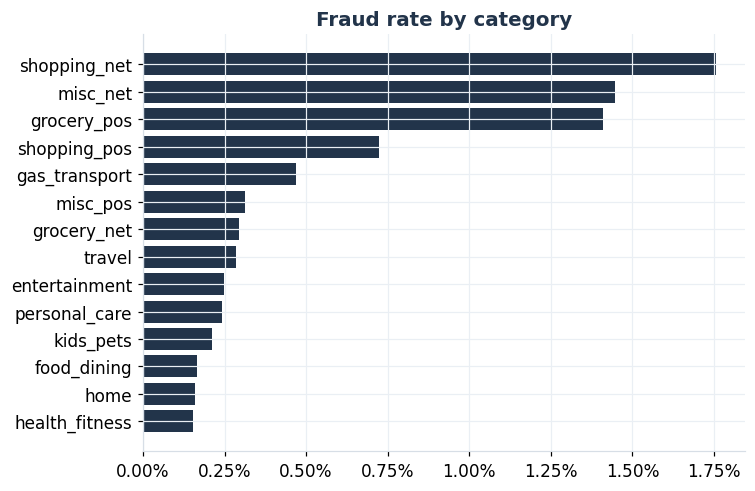

category
shopping_net      1.756
misc_net          1.446
grocery_pos       1.410
shopping_pos      0.723
gas_transport     0.469
misc_pos          0.314
grocery_net       0.295
travel            0.286
entertainment     0.248
personal_care     0.242
kids_pets         0.211
food_dining       0.165
home              0.161
health_fitness    0.155
Name: is_fraud, dtype: float64

In [9]:
cat = df.groupby("category")["is_fraud"].mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(cat.index, cat.values, color=NAVY)
ax.set_title("Fraud rate by category")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout(); plt.show()
cat.sort_values(ascending=False).round(3)

**Read:** the online categories lead – `shopping_net` (1.76%) and `misc_net` (1.45%) top the list, roughly 10× the safest categories (`health_fitness`, `home` ≈ 0.16%). But `grocery_pos` sits third (1.41%), so this isn't a clean card-present vs card-not-present split – in-person point-of-sale is heavily targeted here too. Useful risk context even though category isn't a model input (a category fraud-rate feature would leak the label).

## 6 · When does fraud happen?

Fraud rate by hour of day, plus the night flag (`is_night`, 00:00–05:59).

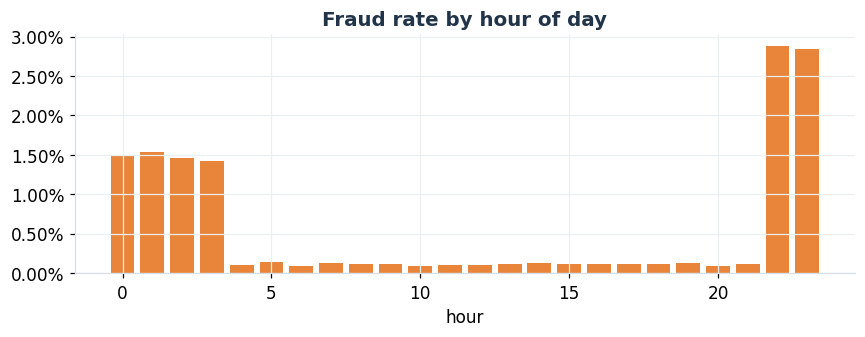

Night (00-05h) fraud rate: 1.033%
Daytime fraud rate:        0.468%


In [10]:
hour = df.groupby("txn_hour")["is_fraud"].mean().mul(100)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(hour.index, hour.values, color=ORANGE)
ax.set_title("Fraud rate by hour of day"); ax.set_xlabel("hour")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout(); plt.show()

night = 100 * df.loc[df.is_night, "is_fraud"].mean()
day = 100 * df.loc[~df.is_night, "is_fraud"].mean()
print(f"Night (00-05h) fraud rate: {night:.3f}%")
print(f"Daytime fraud rate:        {day:.3f}%")

**Read:** fraud skews toward the small hours – **1.03% of night-time (00–05h) transactions are fraud vs 0.47% in the daytime, roughly 2.2× higher** — when genuine cardholders are asleep and less likely to notice. A modest but real signal, and the basis for the `is_night` rule.

---

## Takeaways → modeling

| Feature family | Signal | Decision |
|---|---|---|
| Amount deviation (`amt_zscore`, `amt`, `amt_sum_24h`) | **Strong** | Core features |
| Velocity (`txn_count_24h/7d`) | Mild | Keep, modest weight |
| Time (`is_night`, `txn_hour`) | Mild | Keep |
| Geo (`home_merchant_km`, `implied_kmh`) | **None** (synthetic coords) | Documented negative; `implied_kmh` dropped from matrix |

This is a scientist's narrative, not a kitchen-sink one: features were engineered from domain reasoning, then *tested*, and the matrix in `sql/05_feature_matrix.sql` reflects what actually earned its place. Modeling continues in **`02_model_dev.ipynb`**.